### 1. Загрузите картинку parrots.jpg. Преобразуйте изображение, приведя все значения в интервал от 0 до 1. Для этого можно воспользоваться функцией img_as_float из модуля skimage. Обратите внимание на этот шаг, так как при работе с исходным изображением вы получите некорректный результат.

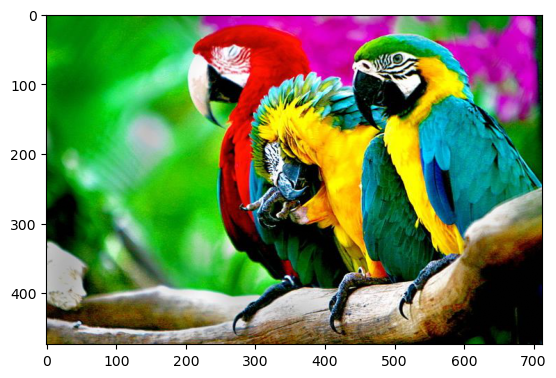

In [1]:
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error
from skimage.io import imread
from skimage import img_as_float
import pylab
import matplotlib.pyplot as plt
import math
import numpy as np

image = imread('parrots.jpg')
image = img_as_float(image)

plt.imshow(image)

### 2. Создайте матрицу объекты-признаки: характеризуйте каждый пиксель тремя координатами - значениями интенсивности в пространстве RGB.

In [2]:
X = image.reshape(-1, 3).copy()  # Преобразование в матрицу объекты-признаки (пиксель - RGB), -1 перемножает h и w

### 3. Запустите алгоритм K-Means с параметрами init='k-means++' и random_state=241. После выделения кластеров все пиксели, отнесенные в один кластер, попробуйте заполнить двумя способами: медианным и средним цветом по кластеру.

In [3]:
def PSNR(original, compressed):
    mse = mean_squared_error(original.flatten(), compressed.flatten())
    if mse == 0:
        return 100  # MSE равен нулю, значит, изображения идентичны
    max_pixel = 1.0
    psnr = 20 * math.log10(max_pixel / math.sqrt(mse))
    return psnr

### 4. Измерьте качество получившейся сегментации с помощью метрики PSNR. Эту метрику нужно реализовать самостоятельно (см. определение).

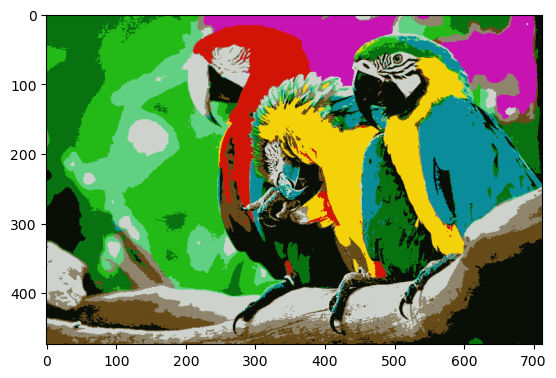

In [4]:
for k in range(2, 21):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=241)
    pred = kmeans.fit_predict(X)

    # 1. Медианный цвет по кластеру
    h, w, c = image.shape
    compressed_med = np.zeros_like(X)
    for i in range(k):
        cluster_pixels = X[pred == i]
        med_color = np.median(cluster_pixels, axis=0)
        compressed_med[pred == i] = med_color
    compressed_med = compressed_med.reshape(h, w, c)
    psnr_med = PSNR(image, compressed_med)

    # 2. Средний цвет
    centers = kmeans.cluster_centers_
    compressed_mean = np.zeros_like(X)
    for i in range(k):
        compressed_mean[pred == i] = centers[i]
    compressed_mean = compressed_mean.reshape(h, w, c)
    psnr_mean = PSNR(image, compressed_mean)

    if psnr_mean > 20 or psnr_med > 20:
        best_k = k
        plt.imshow(compressed_mean)
        plt.show()
        break

### 5. Найдите минимальное количество кластеров, при котором значение PSNR выше 20 (можно рассмотреть не более 20 кластеров, но не забудьте рассмотреть оба способа заполнения пикселей одного кластера). Это число и будет ответом в данной задаче.

In [5]:
print(best_k)

11


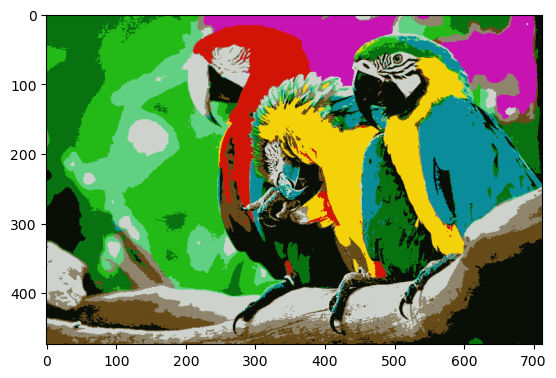

In [6]:
#Общий код для задания
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error
from skimage.io import imread
from skimage import img_as_float
import pylab
import matplotlib.pyplot as plt
import math
import numpy as np

image = imread('parrots.jpg')
image = img_as_float(image)

X = image.reshape(-1,3).copy()

def PSNR(original,compressed):
    mse = mean_squared_error(original.flatten(), compressed.flatten())
    if mse == 0:
        return 100
    max_pixel = 1.0
    psnr = 20 * math.log10(max_pixel / math.sqrt(mse))
    return psnr
    
for k in range(2,21):
    kmeans = KMeans(n_clusters = k,init='k-means++',random_state = 241)
    pred = kmeans.fit_predict(X)
    
    h,w,c = image.shape
    compressed_med = np.zeros_like(X)
    for i in range(k):
        cluster_pixels = X[pred==i]
        med_color = np.median(cluster_pixels,axis = 0)
        compressed_med[pred==i] = med_color
    compressed_med = compressed_med.reshape(h,w,c)
    psnr_med = PSNR(image,compressed_med)

    centers = kmeans.cluster_centers_
    compressed_mean = np.zeros_like(X)
    for i in range(k):
        compressed_mean[pred==i] = centers[i]
    compressed_mean = compressed_mean.reshape(h,w,c)
    psnr_mean = PSNR(image,compressed_mean)

    if psnr_mean > 20 or psnr_med > 20:
        best_k = k
        with open('ans.txt','w') as file:
            file.write(str(best_k))
            plt.imshow(compressed_mean)
            plt.show()
            break